<a href="https://colab.research.google.com/github/taka-yu-ki/AI-research/blob/main/AI%E3%83%BB%E3%83%A1%E3%83%87%E3%82%A3%E3%82%A2%E4%BF%A1%E5%8F%B7%E5%87%A6%E7%90%86%E7%A0%94%E7%A9%B6%E5%AE%A4_%E7%A0%94%E7%A9%B6%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title シミュレーション出力1
import pandas as pd
import csv
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

def main():

    # 不要な括弧や空白を削除する関数
    def clean_string(column):
        if isinstance(column, str):
            return column.replace(")", "").replace("]", "").strip()
        return column

    # 'Ã'をNaNに変換する関数
    def replace_unsafe_characters(column):
        if isinstance(column, str) and "Ã" in column:
            return np.nan
        return column

    # 岩手県釜石港の鮭の漁獲量/隻数のデータパス
    salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イワシ）の漁獲量/隻数のデータパス
    salmon_feed_sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イワシ)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イカ）の漁獲量/隻数のデータパス
    salmon_feed_squid_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イカ)_結合データ.csv"
    # # 岩手県釜石港の平均水温データパス
    average_water_temperature_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水温_結合データ_線形補完.csv"
    # 岩手県釜石港の平均海面気圧データパス
    mean_sea_level_pressure_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_大船渡_海面平均気圧_結合データ.csv"


    # データの読み込み
    salmon_data_df = pd.read_csv(salmon_data_file)
    salmon_feed_sardine_data_df = pd.read_csv(salmon_feed_sardine_data_file)
    salmon_feed_squid_data_df = pd.read_csv(salmon_feed_squid_data_file)
    average_water_temperature_data_df = pd.read_csv(average_water_temperature_data_file)
    mean_sea_level_pressure_data_df = pd.read_csv(mean_sea_level_pressure_data_file)

    # 海面平均気圧データの修正
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(clean_string)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(replace_unsafe_characters)

    # 欠損値を線形補完
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].astype(float)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].interpolate()

    # 学習用データと検証データを設定
    y = salmon_data_df['水揚量_per_隻数']

    merge_data = pd.merge(salmon_feed_sardine_data_df, salmon_feed_squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])
    merge_data = pd.merge(merge_data, mean_sea_level_pressure_data_df, on='日付')
    merge_data = pd.merge(merge_data, average_water_temperature_data_df, on='日付')

    # 説明変数
    X = merge_data[['水揚量_per_隻数_イワシ', '水揚量_per_隻数_イカ', '海面平均気圧(hPa)', '平均水温(℃)']]
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=0)

    # 線形単回帰
    model1 = LinearRegression()
    model1.fit(train_X, train_y)
    print("線形単回帰:", model1.score(test_X, test_y))

    # リッジ回帰
    model2 = Ridge()
    model2.fit(train_X, train_y)
    print("リッジ回帰:", model2.score(test_X, test_y))

    # ラッソ回帰
    model3 = Lasso()
    model3.fit(train_X, train_y)
    print("ラッソ回帰:", model3.score(test_X, test_y))

    # 決定木回帰
    model4 = DecisionTreeRegressor()
    model4.fit(train_X, train_y)
    print("決定木回帰:", model4.score(test_X, test_y))

    # ランダムフォレスト回帰
    model5 = RandomForestRegressor()
    model5.fit(train_X, train_y)
    print("ランダムフォレスト回帰:", model5.score(test_X, test_y))

    # XGBoost回帰
    model6 = XGBRegressor()
    model6.fit(train_X, train_y)
    print("XGBoost回帰:", model6.score(test_X, test_y))

if __name__ == "__main__":
    main()

In [ ]:
# @title シミュレーション出力2
import pandas as pd
import csv
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

def main():

    # 不要な括弧や空白を削除する関数
    def clean_string(column):
        if isinstance(column, str):
            return column.replace(")", "").replace("]", "").strip()
        return column

    # 'Ã'をNaNに変換する関数
    def replace_unsafe_characters(column):
        if isinstance(column, str) and "Ã" in column:
            return np.nan
        return column

    # データパス
    # 岩手県釜石港の鮭の漁獲量/隻数のデータパス
    salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イワシ）の漁獲量/隻数のデータパス
    salmon_feed_sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イワシ)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イカ）の漁獲量/隻数のデータパス
    salmon_feed_squid_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イカ)_結合データ.csv"
    # # 岩手県釜石港の平均水温データパス
    average_water_temperature_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水温_結合データ_線形補完.csv"
    # 岩手県釜石港の平均海面気圧データパス
    mean_sea_level_pressure_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_大船渡_海面平均気圧_結合データ.csv"

    # データの読み込み
    salmon_data_df = pd.read_csv(salmon_data_file)
    salmon_feed_sardine_data_df = pd.read_csv(salmon_feed_sardine_data_file)
    salmon_feed_squid_data_df = pd.read_csv(salmon_feed_squid_data_file)
    average_water_temperature_data_df = pd.read_csv(average_water_temperature_data_file)
    mean_sea_level_pressure_data_df = pd.read_csv(mean_sea_level_pressure_data_file)

    # 学習用データと検証データを設定
    y = salmon_data_df['水揚量_per_隻数']

    merge_data = pd.merge(salmon_feed_sardine_data_df, salmon_feed_squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])
    merge_data = pd.merge(merge_data, mean_sea_level_pressure_data_df, on='日付')
    merge_data = pd.merge(merge_data, average_water_temperature_data_df, on='日付')

    # 説明変数
    X = merge_data[['水揚量_per_隻数_イワシ', '水揚量_per_隻数_イカ', '海面平均気圧(hPa)', '平均水温(℃)']]
    feature_names = X.columns  # 特徴量の名前
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=0)

    # 特徴量重要度を計算して出力する関数
    def get_feature_importance(model, model_name):
        if hasattr(model, "coef_"):  # 線形モデルの場合
            importance = model.coef_
        elif hasattr(model, "feature_importances_"):  # ツリー系モデルの場合
            importance = model.feature_importances_
        else:
            importance = None
        return importance

    # 各モデルの学習と評価
    models = [
        ("線形単回帰", LinearRegression()),
        ("リッジ回帰", Ridge()),
        ("ラッソ回帰", Lasso()),
        ("決定木回帰", DecisionTreeRegressor()),
        ("ランダムフォレスト回帰", RandomForestRegressor()),
        ("XGBoost回帰", XGBRegressor()),
    ]

    results = []

    for name, model in models:
        model.fit(train_X, train_y)
        score = model.score(test_X, test_y)
        importance = get_feature_importance(model, name)
        results.append((name, score, importance))

    # 結果の出力
    for name, score, importance in results:
        print(f"{name}: R^2 = {score}")
        if importance is not None:
            print(f"特徴量重要度: {importance}")
        print("-" * 30)


if __name__ == "__main__":
    main()


In [ ]:
# @title シミュレーション出力3
import pandas as pd
import csv
import numpy as np

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

import matplotlib.pyplot as plt

def main():

    # 不要な括弧や空白を削除する関数
    def clean_string(column):
        if isinstance(column, str):
            return column.replace(")", "").replace("]", "").strip()
        return column

    # 'Ã'をNaNに変換する関数
    def replace_unsafe_characters(column):
        if isinstance(column, str) and "Ã" in column:
            return np.nan
        return column

    # 岩手県釜石港の鮭の漁獲量/隻数のデータパス
    salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イワシ）の漁獲量/隻数のデータパス
    salmon_feed_sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イワシ)_結合データ.csv"
    # 岩手県釜石港の鮭の餌（イカ）の漁獲量/隻数のデータパス
    salmon_feed_squid_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量_per_隻数(イカ)_結合データ.csv"
    # # 岩手県釜石港の平均水温データパス
    average_water_temperature_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水温_結合データ_線形補完.csv"
    # 岩手県釜石港の平均海面気圧データパス
    mean_sea_level_pressure_data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_大船渡_海面平均気圧_結合データ.csv"

    # データの読み込み
    salmon_data_df = pd.read_csv(salmon_data_file)
    salmon_feed_sardine_data_df = pd.read_csv(salmon_feed_sardine_data_file)
    salmon_feed_squid_data_df = pd.read_csv(salmon_feed_squid_data_file)
    average_water_temperature_data_df = pd.read_csv(average_water_temperature_data_file)
    mean_sea_level_pressure_data_df = pd.read_csv(mean_sea_level_pressure_data_file)

    # 海面平均気圧データの修正
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(clean_string)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].apply(replace_unsafe_characters)

    # 欠損値を線形補完
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].astype(float)
    mean_sea_level_pressure_data_df['海面平均気圧(hPa)'] = mean_sea_level_pressure_data_df['海面平均気圧(hPa)'].interpolate()

    # 日付型に変換する
    salmon_data_df['日付'] = pd.to_datetime(salmon_data_df['日付'])

    # # 旬のデータのみを抽出
    # salmon_season_data_df = salmon_data_df[salmon_data_df['日付'].dt.month.isin([1, 4, 5, 6, 9, 10, 11, 12])]

    salmon_data_df

    print(salmon_data_df.query('日付 < 2024-01-01'))

    # 学習用データと検証データを設定
    y = salmon_data_df['水揚量_per_隻数']

    merge_data = pd.merge(salmon_feed_sardine_data_df, salmon_feed_squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])
    merge_data = pd.merge(merge_data, mean_sea_level_pressure_data_df, on='日付')
    merge_data = pd.merge(merge_data, average_water_temperature_data_df, on='日付')

    # 日付型に変換する
    merge_data['日付'] = pd.to_datetime(merge_data['日付'])

    # # 旬のデータのみを抽出
    # merge_season_data = merge_data[merge_data['日付'].dt.month.isin([1, 4, 5, 6, 9, 10, 11, 12])]

    # 説明変数
    X = merge_data[['水揚量_per_隻数_イワシ', '水揚量_per_隻数_イカ', '海面平均気圧(hPa)', '平均水温(℃)']]
    train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.3, random_state=0)

    # 線形回帰モデル
    model1 = LinearRegression()
    model1.fit(train_X, train_y)
    print("線形回帰:", model1.score(test_X, test_y))

    # リッジ回帰
    model2 = Ridge()
    model2.fit(train_X, train_y)
    print("リッジ回帰:", model2.score(test_X, test_y))

    # ラッソ回帰
    model3 = Lasso()
    model3.fit(train_X, train_y)
    print("ラッソ回帰:", model3.score(test_X, test_y))

    # Elastic Net回帰
    model4 = ElasticNet()
    model4.fit(train_X, train_y)
    print("Elastic Net回帰:", model4.score(test_X, test_y))

    # ランダムフォレスト回帰
    model5 = RandomForestRegressor()
    model5.fit(train_X, train_y)
    print("ランダムフォレスト回帰:", model5.score(test_X, test_y))

    # Gradient Boosting回帰
    model6 = GradientBoostingRegressor()
    model6.fit(train_X, train_y)
    print("Gradient Boosting回帰:", model6.score(test_X, test_y))

    # 決定木回帰
    model8 = DecisionTreeRegressor()
    model8.fit(train_X, train_y)
    print("決定木回帰:", model8.score(test_X, test_y))

    # XGBoost回帰
    model9 = XGBRegressor()
    model9.fit(train_X, train_y)
    print("XGBoost回帰:", model9.score(test_X, test_y))

if __name__ == "__main__":
    main()

In [ ]:
# @title pmdarima インストール

!pip install pmdarima

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=122117.093, Time=3.17 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=122159.584, Time=0.14 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(0,0,0)[0]             : AIC=122157.419, Time=0.12 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,0)(0,0,0)[0] intercept   : AIC=122126.746, Time=1.40 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=inf, Time=23.76 sec

Best model:  ARIMA(1,0,1)(0,0,0)[0] intercept
Total fit time: 78.632 seconds
Best ARIMA Model:                                SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 9132
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -61046.908
Date:                Wed, 15 Jan 2025   AIC                         122101.816
Time:                        08:44:02   BIC                         122130.295
Sample:                    01-01-2000   HQIC                        122111.500
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3161      0.481      0.657      0.5

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


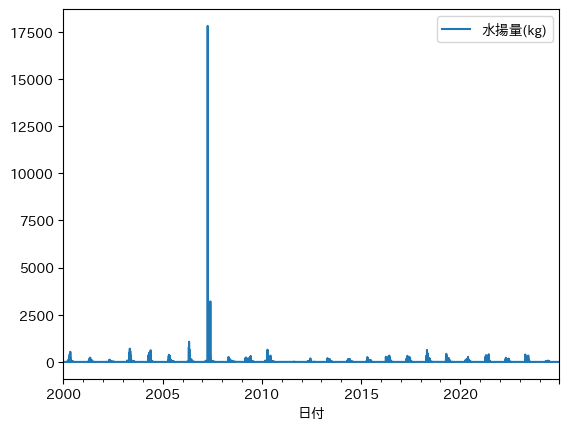

In [ ]:
# @title 時系列解析（ARIMA）

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
from pmdarima import auto_arima

# データパス
data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(サクラマス)_結合データ.csv"

# データの読み込み
data = pd.read_csv(data_file, parse_dates=['日付'], index_col='日付')

# 時系列の可視化
data.plot()

# ARIMAモデルの最適なp, d, qを自動で選択
model_arima = auto_arima(data, seasonal=False, stepwise=True, trace=True)

# 最適なモデルを表示
print(f"Best ARIMA Model: {model_arima.summary()}")

# 予測の実行
forecast_arima = model_arima.predict(n_periods=12)

# モデルの評価
print("ARIMA MSE:", mean_squared_error(data[-12:], forecast_arima))

In [ ]:
# @title 時系列解析（SARIMA）グリッドリサーチ

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools
from sklearn.metrics import mean_squared_error

# ファイルパス
data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(サクラマス)_結合データ.csv"

# データの読み込み
data = pd.read_csv(data_file, parse_dates=['日付'], index_col='日付')

# ARIMAのパラメータ範囲を指定
p_values = range(0, 3)  # ARの次数
d_values = range(0, 2)  # 差分次数
q_values = range(0, 3)  # MAの次数
seasonal_period = 12  # 季節性周期（例: 月単位のデータなら12）

# グリッドサーチで最適な組み合わせを見つける
best_model = None
best_mse = float('inf')
best_order = None
best_seasonal_order = None

# グリッドサーチの進行状況を表示
print("パラメータ探索中...")

for p, d, q in itertools.product(p_values, d_values, q_values):
    seasonal_order = (p, d, q, seasonal_period)  # 季節性のパラメータ
    print(f"試行中のパラメータ: AR({p}), I({d}), MA({q}), 季節性周期({seasonal_period})")

    try:
        sarima_model = SARIMAX(data,
                               order=(p, d, q),  # 非季節性のAR, I, MA
                               seasonal_order=seasonal_order,  # 季節性のAR, I, MA, s
                               enforce_stationarity=False,
                               enforce_invertibility=False)
        sarima_result = sarima_model.fit(disp=False)

        # 予測とMSEの計算
        forecast = sarima_result.forecast(steps=12)
        mse = mean_squared_error(data[-12:], forecast)

        # 最適モデルの更新
        if mse < best_mse:
            best_mse = mse
            best_model = sarima_result
            best_order = (p, d, q)
            best_seasonal_order = seasonal_order
            print(f"最適モデル更新: AR({p}), I({d}), MA({q}), 季節性周期({seasonal_period}), MSE = {mse:.4f}")
    except Exception as e:
        print(f"モデルのフィッティングエラー: {e}")

# 最適モデルとそのパラメータを表示
print(f"\n最適なARIMAモデルのパラメータ: {best_order}")
print(f"最適な季節性パラメータ: {best_seasonal_order}")
print(f"最小MSE: {best_mse:.4f}")

# 最適モデルの予測をプロット
forecast_best_sarima = best_model.forecast(steps=12)
plt.figure(figsize=(10, 6))
plt.plot(data.index, data, label='実データ')
plt.plot(pd.date_range(data.index[-1], periods=13, freq='D')[1:], forecast_best_sarima, label='最適SARIMA予測', color='red')
plt.legend()
plt.show()

            水揚量(kg)
日付                 
2000-01-01      0.0
2000-02-01      0.0
2000-03-01    189.0
2000-04-01   2007.0
2000-05-01   1594.0


/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.10/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                水揚量(kg)   No. Observations:                  300
Model:                        SARIMAX   Log Likelihood               -2567.730
Date:                Tue, 21 Jan 2025   AIC                           5137.460
Time:                        06:34:51   BIC                           5141.160
Sample:                    01-01-2000   HQIC                          5138.941
                         - 12-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       1.68e+06   1.68e+04    100.168      0.000    1.65e+06    1.71e+06
Ljung-Box (L1) (Q):                  27.43   Jarque-Bera (JB):            259331.72
Prob(Q):                              0.00   Pr

/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32080 (\N{CJK UNIFIED IDEOGRAPH-7D50}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23455 (\N{CJK UNIFIED IDEOGRAPH-5B9F}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

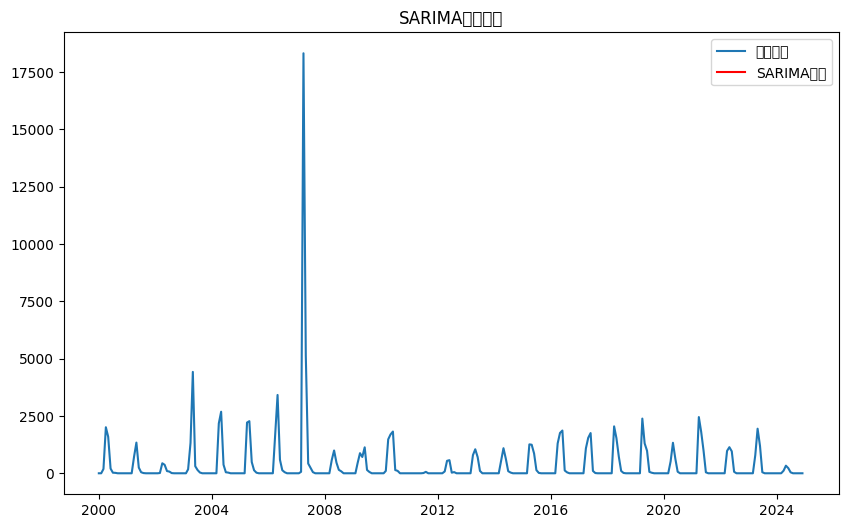

予測された12期間後のデータ:
2025-01-01    0.0
2025-02-01    0.0
2025-03-01    0.0
2025-04-01    0.0
2025-05-01    0.0
2025-06-01    0.0
2025-07-01    0.0
2025-08-01    0.0
2025-09-01    0.0
2025-10-01    0.0
2025-11-01    0.0
2025-12-01    0.0
Freq: MS, Name: predicted_mean, dtype: float64


In [2]:
# @title 時系列解析（SARIMA）

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# ファイルパス
data_file = "/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_水揚量(サクラマス)_結合データ.csv"

# データの読み込み
data = pd.read_csv(data_file, parse_dates=['日付'], index_col='日付')

# 時系列データの確認（最初の数行を表示）
print(data.head())

# 最適なARIMAと季節性パラメータ
best_order = (0, 0, 0)  # ARIMAのパラメータ (p, d, q)
best_seasonal_order = (0, 0, 0, 12)  # 季節性のパラメータ (P, D, Q, S)

# SARIMAモデルの作成
sarima_model = SARIMAX(data,
                       order=best_order,  # 非季節性のAR, I, MA
                       seasonal_order=best_seasonal_order,  # 季節性のAR, I, MA, s
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# モデルのフィッティング
sarima_result = sarima_model.fit(disp=False)

# モデルの概要を表示
print(sarima_result.summary())

# 予測の実行
forecast_steps = 12  # 予測する期間
forecast_best_sarima = sarima_result.forecast(steps=forecast_steps)

# 予測と実データをプロット
plt.figure(figsize=(10, 6))
plt.plot(data.index, data, label='実データ')
plt.plot(pd.date_range(data.index[-1], periods=forecast_steps + 1, freq='D')[1:], forecast_best_sarima, label='SARIMA予測', color='red')
plt.title('SARIMA予測結果')
plt.legend()
plt.show()

# 予測結果を表示
print(f"予測された{forecast_steps}期間後のデータ:")
print(forecast_best_sarima)


In [4]:
# @title 時系列解析（SARIMAX）グリッドリサーチ

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pmdarima as pm
import pandas as pd

# 岩手県釜石港の鮭の餌（サクラマス）の漁獲量のデータパス
salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(サクラマス)_結合データ.csv"

# 岩手県釜石港の鮭の餌（イワシ）の漁獲量のデータパス
sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(イワシ)_結合データ.csv"
# 岩手県釜石港の鮭の餌（イカ）の漁獲量のデータパス
squid_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(イカ)_結合データ.csv"

# 岩手県釜石港の水温（多項式補完）のデータパス
water_temperature_polynomial_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水温_補完/岩手県_釜石港_水温_多項式補完_結合データ.csv"
# 岩手県釜石港の水温（時系列補完）のデータパス
water_temperature_time_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水温_補完/岩手県_釜石港_水温_時系列補完_結合データ.csv"
# 岩手県釜石港の水温（線形補完）のデータパス
water_temperature_linear_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水温_補完/岩手県_釜石港_水温_線形補完_結合データ.csv"

# 岩手県釜石港の平均海面気圧（多項式補完）のデータパス
sea_level_pressure_polynomial_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_大船渡_海面平均気圧_補完/岩手県_大船渡_海面平均気圧_多項式補完_結合データ.csv"
# 岩手県釜石港の平均海面気圧（時系列補完）のデータパス
sea_level_pressure_time_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_大船渡_海面平均気圧_補完/岩手県_大船渡_海面平均気圧_時系列補完_結合データ.csv"
# 岩手県釜石港の平均海面気圧（線形補完）のデータパス
sea_level_pressure_linear_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_大船渡_海面平均気圧_補完/岩手県_大船渡_海面平均気圧_線形補完_結合データ.csv"

# データの読み込み
data = pd.read_csv(salmon_data_file)

# 説明変数の読み込み
sardine_data_df = pd.read_csv(sardine_data_file)
squid_data_df = pd.read_csv(squid_data_file)

water_temperature_polynomial_data_df = pd.read_csv(water_temperature_polynomial_data_file)
water_temperature_time_data_df = pd.read_csv(water_temperature_time_data_file)
water_temperature_linear_data_df = pd.read_csv(water_temperature_linear_data_file)

sea_level_pressure_polynomial_data_df = pd.read_csv(sea_level_pressure_polynomial_data_file)
sea_level_pressure_time_data_df = pd.read_csv(sea_level_pressure_time_data_file)
sea_level_pressure_linear_data_df = pd.read_csv(sea_level_pressure_linear_data_file)

# 外生変数 (例: 他の列を外生変数として使う）
X = pd.merge(sardine_data_df, squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])

# 各補完方法ごとにsuffixを追加してマージ
X = pd.merge(X, water_temperature_polynomial_data_df, on='日付', suffixes=['', '_多項式補完'])
X = pd.merge(X, water_temperature_time_data_df, on='日付', suffixes=['', '_時系列補完'])
X = pd.merge(X, water_temperature_linear_data_df, on='日付', suffixes=['', '_線形補完'])

X = pd.merge(X, sea_level_pressure_polynomial_data_df, on='日付', suffixes=['', '_多項式補完'])
X = pd.merge(X, sea_level_pressure_time_data_df, on='日付', suffixes=['', '_時系列補完'])
X = pd.merge(X, sea_level_pressure_linear_data_df, on='日付', suffixes=['', '_線形補完'])

# '水揚量(kg)'列がターゲット
y = data[['水揚量(kg)']]

# 外生変数として使用する列を選択（例: 平均水温、イワシ、イカなど）
exog = X[['水揚量(kg)_イカ', '水揚量(kg)_イワシ', '平均水温(℃)_時系列補完', '海面平均気圧(hPa)_時系列補完']]  # 必要な列を指定

# auto_arimaによるモデルの最適化
model = pm.auto_arima(y, exogenous=exog,
                      seasonal=True, m=12, # m=12 は季節性（12ヶ月の季節性を仮定）
                      stepwise=True, trace=True,
                      suppress_warnings=True)

# 最適なモデルのサマリーを表示
print(model.summary())

# 最適なパラメータでSARIMAXモデルを作成
sarima_model = SARIMAX(y,
                       order=model.order,  # auto_arimaで得られた非季節性のパラメータ
                       seasonal_order=model.seasonal_order,  # auto_arimaで得られた季節性のパラメータ
                       exog=exog,  # 外生変数を指定
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# モデルのフィッティング
sarima_result = sarima_model.fit(disp=False)

# モデルのサマリー結果を表示
print(sarima_result.summary())

/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=inf, Time=67.74 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=122126.635, Time=0.17 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=122127.330, Time=2.43 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,0,2)(0,0,0)[12] intercept   : AIC=122126.894, Time=2.42 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(0,0,0)[12] intercept   : AIC=inf, Time=22.58 sec


/usr/local/lib/python3.10/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(0,0,0)[12]             : AIC=122113.105, Time=1.52 sec

Best model:  ARIMA(1,0,1)(0,0,0)[12] intercept
Total fit time: 216.817 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 9132
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -61046.908
Date:                Sun, 19 Jan 2025   AIC                         122101.816
Time:                        04:16:33   BIC                         122130.295
Sample:                             0   HQIC                        122111.500
                               - 9132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.3161      0.481      0.657      0.511      -

In [101]:
# @title 時系列解析（SARIMAX）

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

# 岩手県釜石港の鮭の餌（サクラマス）の漁獲量のデータパス
salmon_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(サクラマス)_結合データ.csv"

# 岩手県釜石港の鮭の餌（イワシ）の漁獲量のデータパス
sardine_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(イワシ)_結合データ.csv"
# 岩手県釜石港の鮭の餌（イカ）の漁獲量のデータパス
squid_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(イカ)_結合データ.csv"

# 岩手県釜石港の水温（多項式補完）のデータパス
water_temperature_polynomial_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水温_補完/岩手県_釜石港_水温_多項式補完_結合データ.csv"
# 岩手県釜石港の水温（時系列補完）のデータパス
water_temperature_time_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水温_補完/岩手県_釜石港_水温_時系列補完_結合データ.csv"
# 岩手県釜石港の水温（線形補完）のデータパス
water_temperature_linear_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水温_補完/岩手県_釜石港_水温_線形補完_結合データ.csv"

# 岩手県釜石港の平均海面気圧（多項式補完）のデータパス
sea_level_pressure_polynomial_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_大船渡_海面平均気圧_補完/岩手県_大船渡_海面平均気圧_多項式補完_結合データ.csv"
# 岩手県釜石港の平均海面気圧（時系列補完）のデータパス
sea_level_pressure_time_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_大船渡_海面平均気圧_補完/岩手県_大船渡_海面平均気圧_時系列補完_結合データ.csv"
# 岩手県釜石港の平均海面気圧（線形補完）のデータパス
sea_level_pressure_linear_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_大船渡_海面平均気圧_補完/岩手県_大船渡_海面平均気圧_線形補完_結合データ.csv"

# データの読み込み
data = pd.read_csv(salmon_data_file)

# 説明変数の読み込み
sardine_data_df = pd.read_csv(sardine_data_file)
squid_data_df = pd.read_csv(squid_data_file)

water_temperature_polynomial_data_df = pd.read_csv(water_temperature_polynomial_data_file)
water_temperature_time_data_df = pd.read_csv(water_temperature_time_data_file)
water_temperature_linear_data_df = pd.read_csv(water_temperature_linear_data_file)

sea_level_pressure_polynomial_data_df = pd.read_csv(sea_level_pressure_polynomial_data_file)
sea_level_pressure_time_data_df = pd.read_csv(sea_level_pressure_time_data_file)
sea_level_pressure_linear_data_df = pd.read_csv(sea_level_pressure_linear_data_file)

# 外生変数 (例: 他の列を外生変数として使う）
X = pd.merge(sardine_data_df, squid_data_df, on='日付', suffixes=['_イワシ', '_イカ'])
X = pd.merge(X, water_temperature_polynomial_data_df, on='日付')
X = pd.merge(X, sea_level_pressure_polynomial_data_df, on='日付')

# SARIMAモデルを作成（例: ARIMA(1,0,1) + 季節性パラメータ(0,0,0,12)）
sarima_model = SARIMAX(data[['水揚量(kg)']],  # 予測したい変数
                       order=(1, 0, 1),  # 非季節性のAR, I, MA
                       seasonal_order=(0, 0, 0, 12),  # 季節性のAR, I, MA, s
                       exog=X[['平均水温(℃)']],  # 外生変数を指定
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# モデルのフィッティング
sarima_result = sarima_model.fit(disp=False)

# モデルのサマリー結果を表示
print(sarima_result.summary())


                               SARIMAX Results                                
Dep. Variable:                水揚量(kg)   No. Observations:                 9132
Model:               SARIMAX(1, 0, 1)   Log Likelihood              -61041.631
Date:                Wed, 15 Jan 2025   AIC                         122091.262
Time:                        10:06:06   BIC                         122119.739
Sample:                             0   HQIC                        122100.945
                               - 9132                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
平均水温(℃)        0.2408      1.523      0.158      0.874      -2.743       3.225
ar.L1          0.9789      0.007    140.536      0.000       0.965       0.993
ma.L1         -0.9646      0.008   -114.373      0.0

In [ ]:
# @title 岩手県釜石港 漁港データ スクレイピング
import os
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime, timedelta

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-15'

# 釜石の地点
place = '2'

while date.strftime('%Y-%m-%d') != goal_date:
    # 現在の日付をコンソールに出力
    print(f"Processing date: {date.strftime('%Y-%m-%d')}")

    # 岩手県釜石湾の漁獲量関連のデータにアクセスする
    url = "https://www.suigi.pref.iwate.jp/shikyo/daily/report/" + year + "/" + month + "/" + day + "/" + place
    print(f"Accessing URL: {url}")  # URLの確認

    response = requests.get(url)

    # BeautifulSoup で HTML を解析
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = []

    # 各要素の名前、要素数の取得
    headers = soup.find('tr', {'style': 'height:9.0pt;border-left:none;'})

    if headers is not None:
        print("Data found, processing...")  # データが見つかった場合のログ
        # 各要素の名前を datas に格納
        datas.append([str(header.text) for header in headers.find_all('td')])

        # データが入っている階層の class 要素を取得
        tds = soup.find_all('td', {'class': 'shikyo_daily_report_td_fishing_cd'})

        for td in tds:
            # 親要素を取得
            tr = td.parent

            # データの \xa0 を空文字に変換して datas に格納
            datas.append([td.text.replace('\xa0', '') if isinstance(td.text, str) else td.text for td in tr.find_all('td')])

        # 保存先ディレクトリの作成
        directory = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{date.strftime('%Y')}/{date.strftime('%m')}/"
        if not os.path.exists(directory):
            os.makedirs(directory)
            print(f"フォルダを作成しました。: {directory}")  # フォルダ作成ログ

        # データを csv に書き込む
        file_path = f"{directory}{date.strftime('%d')}.csv"
        with open(file_path, 'w', encoding='utf-8') as f:
            writer = csv.writer(f)
            for data in datas:
                writer.writerow(data)
        print(f"データを保存しました。: {file_path}")  # 保存完了ログ

    else:
        print("データが見つかりませんでした。")  # データが見つからなかった場合

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

In [ ]:
# @title 岩手県釜石港 水温データ スクレイピング
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2025-01-01'

# 釜石の地点
place = 3

while date.strftime('%Y-%m-%d') < goal_date:
    # 月初めにURLとデータリストの初期化
    if date.day == 1:
        url = f"https://www.suigi.pref.iwate.jp/teichi/monthly/report/{date.strftime('%Y')}/{date.strftime('%m')}"
        response = requests.get(url)
        soup = BeautifulSoup(response.text, "html.parser")
        tds = soup.find_all('td', {'class': 'monthly_report_detail_table_th_date'})

        # 月ごとのデータリストを初期化し、ヘッダーを追加
        datas = [["日付", "平均水温(℃)"]]
        print(f"\n--- {date.strftime('%Y年%m月')} のデータ収集を開始 ---")

    # データが存在する場合
    if date.day <= len(tds):
        tr = tds[date.day - 1].parent
        water_temperature_data = tr.select_one('td:nth-of-type(8)').text
        datas.append([date.strftime('%Y-%m-%d'), water_temperature_data])

        # 途中経過を出力
        print(f"取得日: {date.strftime('%Y-%m-%d')} - 平均水温(℃): {water_temperature_data}")

    # 月末に到達した場合、その月のデータをCSVに保存
    if (date + delta).month != date.month:
        # 出力ディレクトリとファイルの作成
        output_dir = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水温_データ/{date.strftime('%Y')}"
        os.makedirs(output_dir, exist_ok=True)

        # 月ごとのCSVファイルの保存
        output_path = os.path.join(output_dir, f"{date.strftime('%m')}.csv")
        with open(output_path, 'w', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerows(datas)
        print(f"データを保存しました: {output_path}")

    # 日付を1日進める
    date += delta

In [ ]:
# @title 岩手県大船渡 平均気圧データ スクレイピング
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import numpy as np

# -----------------------------------------------------------------------------------------------------------------------------
# 不要な括弧や空白を削除する関数
def clean_string(column):
    if isinstance(column, str):
        return column.replace(")", "").replace("]", "").strip()
    return column

# 'Ã'をNaNに変換する関数
def replace_unsafe_characters(column):
    if isinstance(column, str) and "Ã" in column:
        return np.nan
    return column

# -----------------------------------------------------------------------------------------------------------------------------
# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 大船渡の場所
place = '47512'
# -----------------------------------------------------------------------------------------------------------------------------
while date.strftime('%Y-%m-%d') != goal_date:

    # 岩手県大船渡の海面平均気圧データにアクセスする
    url = "https://www.data.jma.go.jp/obd/stats/etrn/view/daily_s1.php?prec_no=33&block_no=" + place + "&year=" + year + "&month=" + month + "&day=&view=a1s"

    # 進捗を表示
    print(f"スクレイピング中: {date.strftime('%Y-%m-%d')} URL: {url}")

    response = requests.get(url)

    # BeautifulSoup で HTML を解析
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = []

    # ヘッダーの追加
    datas.append(["日付", "海面平均気圧(hPa)"])

    # テーブルの取得
    table = soup.find('table', {'class': 'data2_s', 'id': 'tablefix1'})

    if table:
        # 行の取得
        trs = table.find_all('tr', {'style': 'text-align:right;'})

        # データを格納
        for tr in trs:
            number = int(tr.find('div', {'class': 'a_print'}).text)
            data = [td.text for td in tr.find_all('td')]

            # 日付と気圧を処理
            date_value = str(year) + "-" + str(month) + "-" + str(f"{number:02}")
            pressure_value = clean_string(data[2])  # 不要な文字を削除
            pressure_value = replace_unsafe_characters(pressure_value)  # 'Ã'をNaNに変換

            # 処理後のデータを格納
            datas.append([date_value, pressure_value])

        # データを csv に書き込む
        with open(f"/content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_海面平均気圧_データ/{date.strftime('%Y')}/{date.strftime('%m')}.csv", 'w', encoding='utf-8') as f:
            writer = csv.writer(f)
            for data in datas:
                writer.writerow(data)

        print(f"{date.strftime('%Y-%m')} のデータを保存しました")
    else:
        print(f"{date.strftime('%Y-%m')} のデータが見つかりませんでした")

    # 1日後
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')

print("スクレイピング完了")

In [ ]:
# @title 岩手県大船渡 降水量データ スクレイピング
import os
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime
from dateutil.relativedelta import relativedelta
import numpy as np

# -----------------------------------------------------------------------------------------------------------------------------

# 不要な括弧や空白を削除する関数
def clean_string(column):
    if isinstance(column, str):
        return column.replace(")", "").replace("]", "").strip()
    return column

# 'Ã'をNaNに変換する関数
def replace_unsafe_characters(column):
    if isinstance(column, str) and "Ã" in column:
        return ''
    return column

# '--' を NaN に変換する関数を追加
def replace_hyphen_with_nan(column):
    if isinstance(column, str) and "--" in column:
        return ''
    return column

# -----------------------------------------------------------------------------------------------------------------------------

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(months=1)

# 目標日付
goal_date = '2024-12-31'

# 大船渡の場所
place = '47512'

# -----------------------------------------------------------------------------------------------------------------------------

while date.strftime('%Y-%m-%d') <= goal_date:
    # URLの設定
    url = f"https://www.data.jma.go.jp/obd/stats/etrn/view/daily_s1.php?prec_no=33&block_no={place}&year={date.year}&month={date.month:02d}&day=&view=a1s"

    # 進捗を表示
    print(f"スクレイピング中: {date.strftime('%Y-%m')} URL: {url}")

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = [["日付", "降水量(mm)"]]

    # テーブルの取得
    table = soup.find('table', {'class': 'data2_s', 'id': 'tablefix1'})

    if table:
        # 行の取得
        trs = table.find_all('tr', {'style': 'text-align:right;'})

        # データを格納
        for tr in trs:
            number = int(tr.find('div', {'class': 'a_print'}).text)
            data = [td.text for td in tr.find_all('td')]

            # 日付と気圧を処理
            date_value = f"{date.year}-{date.month:02d}-{number:02d}"
            pressure_value = clean_string(data[5]) # 不要な文字を削除
            pressure_value = replace_unsafe_characters(pressure_value) # 'Ã'をNaNに変換
            pressure_value = replace_hyphen_with_nan(pressure_value) # '--'をNaNに変換

            # 処理後のデータを格納
            datas.append([date_value, pressure_value])

        # 保存先ディレクトリのパス
        save_dir = f"/content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_降水量_データ/{date.year}"

        # ディレクトリが存在しない場合は作成
        os.makedirs(save_dir, exist_ok=True)

        # データをCSVに書き込む
        save_path = os.path.join(save_dir, f"{date.month:02d}.csv")
        with open(save_path, 'w', encoding='utf-8', newline='') as f:
            writer = csv.writer(f)
            writer.writerows(datas)

        print(f"{date.strftime('%Y-%m')} のデータを保存しました: {save_path}")
    else:
        print(f"{date.strftime('%Y-%m')} のデータが見つかりませんでした")

    # 次の月へ
    date += delta

print("スクレイピング完了")


In [ ]:
# @title 岩手県釜石港 降水量データ スクレイピング
import os
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime
from dateutil.relativedelta import relativedelta
import numpy as np

# -----------------------------------------------------------------------------------------------------------------------------

# 不要な括弧や空白を削除する関数
def clean_string(column):
    if isinstance(column, str):
        return column.replace(")", "").replace("]", "").strip()
    return column

# 'Ã'をNaNに変換する関数
def replace_unsafe_characters(column):
    if isinstance(column, str) and "Ã" in column:
        return ''
    return column

# '--' を NaN に変換する関数を追加
def replace_hyphen_with_nan(column):
    if isinstance(column, str) and "--" in column:
        return ''
    return column

# -----------------------------------------------------------------------------------------------------------------------------

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(months=1)

# 目標日付
goal_date = '2024-12-31'

# 釜石市の場所
place = '0233'

# -----------------------------------------------------------------------------------------------------------------------------

while date.strftime('%Y-%m-%d') <= goal_date:
    # URLの設定
    url = f"https://www.data.jma.go.jp/obd/stats/etrn/view/daily_a1.php?prec_no=33&block_no={place}&year={date.year}&month={date.month:02d}&day=&view=p1"

    # 進捗を表示
    print(f"スクレイピング中: {date.strftime('%Y-%m')} URL: {url}")

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = [["日付", "平均風速(m/s)"]]

    # テーブルの取得
    table = soup.find('table', {'class': 'data2_s', 'id': 'tablefix1'})

    if table:
        # 行の取得
        trs = table.find_all('tr', {'style': 'text-align:right;'})

        # データを格納
        for tr in trs:
            number = int(tr.find('div', {'class': 'a_print'}).text)
            data = [td.text for td in tr.find_all('td')]

            # 日付と気圧を処理
            date_value = f"{date.year}-{date.month:02d}-{number:02d}"
            pressure_value = clean_string(data[9]) # 不要な文字を削除
            pressure_value = replace_unsafe_characters(pressure_value) # 'Ã'をNaNに変換
            pressure_value = replace_hyphen_with_nan(pressure_value) # '--'をNaNに変換

            # 処理後のデータを格納
            datas.append([date_value, pressure_value])

        # 保存先ディレクトリのパス
        save_dir = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_風速_データ/{date.year}"

        # ディレクトリが存在しない場合は作成
        os.makedirs(save_dir, exist_ok=True)

        # データをCSVに書き込む
        save_path = os.path.join(save_dir, f"{date.month:02d}.csv")
        with open(save_path, 'w', encoding='utf-8', newline='') as f:
            writer = csv.writer(f)
            writer.writerows(datas)

        print(f"{date.strftime('%Y-%m')} のデータを保存しました: {save_path}")
    else:
        print(f"{date.strftime('%Y-%m')} のデータが見つかりませんでした")

    # 次の月へ
    date += delta

print("スクレイピング完了")


In [41]:
# @title 岩手県大船渡 天気データ スクレイピング

import os
import requests
from bs4 import BeautifulSoup
import csv
from datetime import datetime
from dateutil.relativedelta import relativedelta
import numpy as np

# -----------------------------------------------------------------------------------------------------------------------------

# 不要な括弧や空白を削除する関数
def clean_string(column):
    if isinstance(column, str):
        return column.replace(")", "").replace("]", "").strip()
    return column

# 'Ã'をNaNに変換する関数
def replace_unsafe_characters(column):
    if isinstance(column, str) and "Ã" in column:
        return ''
    return column

# '--' を NaN に変換する関数を追加
def replace_hyphen_with_nan(column):
    if isinstance(column, str) and "--" in column:
        return ''
    return column

# -----------------------------------------------------------------------------------------------------------------------------

# 初期日付
year = '2015'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2015-01-15'

# 大船渡の場所
place = '47512'

# -----------------------------------------------------------------------------------------------------------------------------

while date.strftime('%Y-%m-%d') <= goal_date:
    # URLの設定
    url = f"https://tenki.jp/past/{year}/{month}/{day}/weather/2/6/{place}/"

    # 進捗を表示
    print(f"スクレイピング中: {date.strftime('%Y-%m')} URL: {url}")

    response = requests.get(url)
    soup = BeautifulSoup(response.text, "html.parser")

    # データの配列を作成
    datas = [["日付", "天気"]]

    # テーブルの取得
    table = soup.find('table', {'class': 'past-live-point-table'})

    if table:
        # 行の取得
        trs = table.find_all('tr')

        # データを格納
        for tr in trs:
            th = tr.find('th', {'class': 'weather-index'})

            if th:
                td = tr.find_all('td', {'class': 'weather-entry'})[1]  # 2番目の<td>を取得

                # 天気を取得
                weather = td.get_text(strip=True)

                print(weather)

                # 日付と気圧を処理
                date_value = f"{date.year}-{date.month:02d}-{number:02d}"

                # 処理後のデータを格納
                datas.append([date_value, pressure_value])

                # 保存先ディレクトリのパス
                save_dir = f"/content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/{date.year}"

                # ディレクトリが存在しない場合は作成
                os.makedirs(save_dir, exist_ok=True)

                # データをCSVに書き込む
                save_path = os.path.join(save_dir, f"{date.month:02d}.csv")
                with open(save_path, 'w', encoding='utf-8', newline='') as f:
                    writer = csv.writer(f)
                    writer.writerows(datas)

        print(f"{date.strftime('%Y-%m')} のデータを保存しました: {save_path}")
    else:
        print(f"{date.strftime('%Y-%m')} のデータが見つかりませんでした")

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

print("スクレイピング完了")


スクレイピング中: 2015-01 URL: https://tenki.jp/past/2015/01/01/weather/2/6/47512/
不明
2015-01 のデータを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/2015/01.csv
スクレイピング中: 2015-01 URL: https://tenki.jp/past/2015/01/02/weather/2/6/47512/
不明
2015-01 のデータを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/2015/01.csv
スクレイピング中: 2015-01 URL: https://tenki.jp/past/2015/01/03/weather/2/6/47512/
雪
2015-01 のデータを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/2015/01.csv
スクレイピング中: 2015-01 URL: https://tenki.jp/past/2015/01/04/weather/2/6/47512/
不明
2015-01 のデータを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/2015/01.csv
スクレイピング中: 2015-01 URL: https://tenki.jp/past/2015/01/05/weather/2/6/47512/
不明
2015-01 のデータを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/2015/01.csv
スクレイピング中: 2015-01 URL: https://tenki.jp/past/2015/01/06/weather/2/6/47512/
不明
2015-01 のデータを保存しました: /content/drive/MyDrive/研究用/AI-research/岩手県_大船渡_天気_データ/2015/01.csv
スクレイピング中: 2

In [ ]:
# @title サクラマスの漁獲量 取得
import pandas as pd
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

# 全期間の日数を計算
total_days = (datetime.strptime(goal_date, '%Y-%m-%d') - date).days + 1
processed_days = 0

while date.strftime('%Y-%m-%d') <= goal_date:

    # 現在の処理日を表示
    print(f"処理中の日付: {date.strftime('%Y-%m-%d')}")

    # CSVファイルの読み込みパス
    file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{year}/{month}/{day}.csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # 鮭（サケ、マス）の漁獲量を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('サクラマス', na=False)]

        # '水揚量(kg)' 列の文字列からカンマを取り除き、数値に変換
        dayily_salmon_catch_df['水揚量(kg)'] = dayily_salmon_catch_df['水揚量(kg)'].replace(',', '', regex=True).astype(float)

        # 水揚量列の合計を取得
        total_weight = dayily_salmon_catch_df['水揚量(kg)'].sum()
    else:
        # データが存在しない場合、水揚量を0.0とする
        total_weight = 0.0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "-" + month + "-" + day], '水揚量(kg)': [total_weight]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(鮭)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

    # 処理済み日数を更新
    processed_days += 1
    progress = (processed_days / total_days) * 100
    print(f"進捗: {progress:.2f}% 完了")

print("すべての処理が完了しました！")

In [ ]:
# @title サクラマスの隻数 取得
import pandas as pd
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '隻数'])

# 全期間の日数を計算
total_days = (datetime.strptime(goal_date, '%Y-%m-%d') - date).days + 1
processed_days = 0

while date.strftime('%Y-%m-%d') <= goal_date:

    # 現在の処理日を表示
    print(f"処理中の日付: {date.strftime('%Y-%m-%d')}")

    # CSVファイルの読み込みパス
    file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{year}/{month}/{day}.csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # サクラマスの隻数を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('サクラマス', na=False)]

        # '隻数' 列を数値に変換
        dayily_salmon_catch_df['隻数'] = dayily_salmon_catch_df['隻数'].astype(float)

        # '隻数'列の合計を取得
        total_num = dayily_salmon_catch_df['隻数'].sum().astype(int)
    else:
        # データが存在しない場合、隻数を0とする
        total_num = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "-" + month + "-" + day], '隻数': [total_num]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_隻数(サクラマス)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '隻数'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

    # 処理済み日数を更新
    processed_days += 1
    progress = (processed_days / total_days) * 100
    print(f"進捗: {progress:.2f}% 完了")

print("すべての処理が完了しました！")


In [ ]:
# @title イワシの漁獲量 取得
import pandas as pd
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

# 全期間の日数を計算
total_days = (datetime.strptime(goal_date, '%Y-%m-%d') - date).days + 1
processed_days = 0

while date.strftime('%Y-%m-%d') <= goal_date:

    # 現在の処理日を表示
    print(f"処理中の日付: {date.strftime('%Y-%m-%d')}")

    # CSVファイルの読み込みパス
    file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{year}/{month}/{day}.csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # イワシの漁獲量を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イワシ', na=False)]

        # '水揚量(kg)' 列の文字列からカンマを取り除き、数値に変換
        dayily_salmon_catch_df['水揚量(kg)'] = dayily_salmon_catch_df['水揚量(kg)'].replace(',', '', regex=True).astype(float)

        # 水揚量列の合計を取得
        total_weight = dayily_salmon_catch_df['水揚量(kg)'].sum()
    else:
        # データが存在しない場合、水揚量を0とする
        total_weight = 0.0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "-" + month + "-" + day], '水揚量(kg)': [total_weight]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(イワシ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

    # 処理済み日数を更新
    processed_days += 1
    progress = (processed_days / total_days) * 100
    print(f"進捗: {progress:.2f}% 完了")

print("すべての処理が完了しました！")

In [ ]:
# @title イワシの隻数 取得
import pandas as pd
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '隻数'])

# 全期間の日数を計算
total_days = (datetime.strptime(goal_date, '%Y-%m-%d') - date).days + 1
processed_days = 0

while date.strftime('%Y-%m-%d') <= goal_date:

    # 現在の処理日を表示
    print(f"処理中の日付: {date.strftime('%Y-%m-%d')}")

    # CSVファイルの読み込みパス
    file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{year}/{month}/{day}.csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # イワシの隻数を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イワシ', na=False)]

        # '隻数' 列を数値に変換
        dayily_salmon_catch_df['隻数'] = dayily_salmon_catch_df['隻数'].astype(float)

        # '隻数'列の合計を取得
        total_num = dayily_salmon_catch_df['隻数'].sum().astype(int)
    else:
        # データが存在しない場合、隻数を0とする
        total_num = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "-" + month + "-" + day], '隻数': [total_num]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_隻数(イワシ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '隻数'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

    # 処理済み日数を更新
    processed_days += 1
    progress = (processed_days / total_days) * 100
    print(f"進捗: {progress:.2f}% 完了")

print("すべての処理が完了しました！")

In [ ]:
# @title イカの漁獲量 取得
import pandas as pd
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

# 全期間の日数を計算
total_days = (datetime.strptime(goal_date, '%Y-%m-%d') - date).days + 1
processed_days = 0

while date.strftime('%Y-%m-%d') <= goal_date:

    # 現在の処理日を表示
    print(f"処理中の日付: {date.strftime('%Y-%m-%d')}")

    # CSVファイルの読み込みパス
    file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{year}/{month}/{day}.csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # イカの漁獲量を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イカ', na=False)]

        # '水揚量(kg)' 列の文字列からカンマを取り除き、数値に変換
        dayily_salmon_catch_df['水揚量(kg)'] = dayily_salmon_catch_df['水揚量(kg)'].replace(',', '', regex=True).astype(float)

        # 水揚量列の合計を取得
        total_weight = dayily_salmon_catch_df['水揚量(kg)'].sum()
    else:
        # データが存在しない場合、水揚量を0とする
        total_weight = 0.0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "-" + month + "-" + day], '水揚量(kg)': [total_weight]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_水揚量(イカ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '水揚量(kg)'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

    # 処理済み日数を更新
    processed_days += 1
    progress = (processed_days / total_days) * 100
    print(f"進捗: {progress:.2f}% 完了")

print("すべての処理が完了しました！")

In [ ]:
# @title イカの隻数 取得
import pandas as pd
from datetime import datetime, timedelta
import os

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = timedelta(days=1)

# 目標日付
goal_date = '2024-12-31'

# 初期月を保存
current_month = month

# 月毎のDataFrameを準備
monthly_data = pd.DataFrame(columns=['日付', '隻数'])

# 全期間の日数を計算
total_days = (datetime.strptime(goal_date, '%Y-%m-%d') - date).days + 1
processed_days = 0

while date.strftime('%Y-%m-%d') <= goal_date:

    # 現在の処理日を表示
    print(f"処理中の日付: {date.strftime('%Y-%m-%d')}")

    # CSVファイルの読み込みパス
    file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_データ/{year}/{month}/{day}.csv"

    # CSVファイルの存在確認
    if os.path.exists(file_path):
        # CSVファイルを読み込み
        dayily_catch_df = pd.read_csv(file_path)

        # イワシの隻数を取得
        dayily_salmon_catch_df = dayily_catch_df[dayily_catch_df['魚種（銘柄）'].str.contains('イカ', na=False)]

        # '隻数' 列を数値に変換
        dayily_salmon_catch_df['隻数'] = dayily_salmon_catch_df['隻数'].astype(float)

        # '隻数'列の合計を取得
        total_num = dayily_salmon_catch_df['隻数'].sum().astype(int)
    else:
        # データが存在しない場合、隻数を0とする
        total_num = 0

    # 結果をDataFrameに追加
    monthly_data = pd.concat([monthly_data, pd.DataFrame({'日付': [year + "-" + month + "-" + day], '隻数': [total_num]})], ignore_index=True)

    # 月が変わったらデータを保存し、monthly_dataを初期化
    next_month = (date + delta).strftime('%m')
    if next_month != current_month:
        # 保存
        output_file_path = f"/content/drive/MyDrive/研究用/AI-research/岩手県_釜石港_隻数(イカ)_データ/{year}/{current_month}.csv"
        monthly_data.to_csv(output_file_path, index=False, encoding='utf-8-sig')
        print(f"データが {output_file_path} に保存されました。")

        # monthly_dataを初期化
        monthly_data = pd.DataFrame(columns=['日付', '隻数'])

        # 現在の月を更新
        current_month = next_month

    # 1日追加
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')
    day = date.strftime('%d')

    # 処理済み日数を更新
    processed_days += 1
    progress = (processed_days / total_days) * 100
    print(f"進捗: {progress:.2f}% 完了")

print("すべての処理が完了しました！")

In [ ]:
# @title 日毎の結合データ 作成

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import os
import numpy as np

# -----------------------------------------------------------------------------------------------------------------------------

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(months=1)

# 目標日付
goal_date = '2024-12-31'

# データを保存するリストを作成
data_frames = []

# 対象データ名
data_name = '岩手県_大船渡_降水量'

# 対象のフォルダとファイル名のパスを定義
base_folder = f"/content/drive/MyDrive/研究用/AI-research/{data_name}_データ/"

# -----------------------------------------------------------------------------------------------------------------------------
while date.strftime('%Y-%m-%d') <= goal_date:
    # ファイルパスの作成
    file_path = os.path.join(base_folder, f"{year}/{month}.csv")

    # ファイルが存在する場合のみ読み込み
    if os.path.exists(file_path):
        # CSVを読み込んでリストに追加
        df = pd.read_csv(file_path)
        data_frames.append(df)
        print(f"{file_path} が正常に読み込まれました。")  # 途中結果を表示
        print(f"現在のデータフレームの行数: {len(df)} 行")
    else:
        print(f"ファイルが見つかりませんでした: {file_path}")

    # 1ヶ月後
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')

# 全てのデータフレームを結合
merged_data = pd.concat(data_frames, ignore_index=True)

# 結果をCSVとして保存（必要に応じてファイル名を指定）
output_path = f"/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/{data_name}_結合データ.csv"
merged_data.to_csv(output_path, index=False)

print(f"結合が完了しました！出力先: {output_path}")

In [ ]:
# @title 日毎の結合データ 補完 作成

from datetime import datetime
from dateutil.relativedelta import relativedelta
import pandas as pd
import os

# -----------------------------------------------------------------------------------------------------------------------------

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(months=1)

# 目標日付
goal_date = '2024-12-31'

# データを保存するリストを作成
data_frames = []

# 対象データ名
data_name = '岩手県_釜石港_風速'

# データカラム名
data_column_name = '平均風速(m/s)'

# 対象のフォルダとファイル名のパスを定義
base_folder = f"/content/drive/MyDrive/研究用/AI-research/{data_name}_データ/"

# 保存先フォルダのパス
output_folder = f"/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/{data_name}_補完/"
os.makedirs(output_folder, exist_ok=True)  # フォルダを作成（存在しない場合のみ）

# -----------------------------------------------------------------------------------------------------------------------------

def apply_interpolation(df, method='線形補完'):
    df[data_column_name] = pd.to_numeric(df[data_column_name], errors='coerce')  # 数値型に変換
    if method == '線形補完':
        df[data_column_name] = df[data_column_name].interpolate(method='linear')
    elif method == '時系列補完':
        df['日付'] = pd.to_datetime(df['日付'], errors='coerce')  # 日付型に変換
        df.set_index('日付', inplace=True)
        df[data_column_name] = df[data_column_name].interpolate(method='time')
        df.reset_index(inplace=True)
    elif method == '多項式補完':
        df[data_column_name] = df[data_column_name].interpolate(method='polynomial', order=2)
    else:
        raise ValueError("Unsupported interpolation method")

    # マイナスの値を0に置き換え
    df[data_column_name] = df[data_column_name].clip(lower=0)

    return df

# -----------------------------------------------------------------------------------------------------------------------------

while date.strftime('%Y-%m-%d') <= goal_date:
    # ファイルパスの作成
    file_path = os.path.join(base_folder, f"{year}/{month}.csv")

    # ファイルが存在する場合のみ読み込み
    if os.path.exists(file_path):
        # CSVを読み込んでリストに追加
        df = pd.read_csv(file_path)
        data_frames.append(df)
        print(f"{file_path} が正常に読み込まれました。")
    else:
        print(f"ファイルが見つかりませんでした: {file_path}")

    # 1ヶ月後
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')

# 全てのデータフレームを結合
merged_data = pd.concat(data_frames, ignore_index=True)

# -----------------------------------------------------------------------------------------------------------------------------

# 補完方法のリスト
interpolation_methods = ['線形補完', '時系列補完', '多項式補完']

# 各補完方法を適用し、異なる出力ファイル名で保存
for method in interpolation_methods:
    # 元のデータフレームをコピーして補完を適用
    interpolated_data = apply_interpolation(merged_data.copy(), method)

    # 出力ファイル名の作成（補完方法を反映）
    output_path = os.path.join(output_folder, f"{data_name}_{method}_結合データ.csv")

    # 結果をCSVとして保存
    interpolated_data.to_csv(output_path, index=False, encoding='utf-8')

    print(f"{method}が完了しました！出力先: {output_path}")

In [ ]:
# @title 月毎のデータ 作成

from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pandas as pd
import os
import numpy as np

# -----------------------------------------------------------------------------------------------------------------------------

# 初期日付
year = '2000'
month = '01'
day = '01'
date = datetime(int(year), int(month), int(day))

# 日付間隔の設定
delta = relativedelta(months=1)

# 目標日付
goal_date = '2024-12-31'

# データを保存するリストを作成
data_frames = []

# 処理タイプ（"total"または"avg"）
process_type = "avg"

# 対象データ名
data_name = '岩手県_大船渡_海面平均気圧'

# 対象のフォルダとファイル名のパスを定義
base_folder = f"/content/drive/MyDrive/研究用/AI-research/{data_name}_データ/"

# -----------------------------------------------------------------------------------------------------------------------------

while date.strftime('%Y-%m-%d') <= goal_date:
    # ファイルパスの作成
    file_path = os.path.join(base_folder, f"{year}/{month}.csv")

    # ファイルが存在する場合のみ読み込み
    if os.path.exists(file_path):
        # CSVを読み込んでリストに追加
        df = pd.read_csv(file_path)

        # 各列に対してclean_stringとreplace_unsafe_characters関数を適用
        df = df.applymap(clean_string)  # 不要な括弧や空白を削除
        df = df.applymap(replace_unsafe_characters)  # 'Ã'をNaNに変換

        data_frames.append(df)
        print(f"{file_path} が正常に読み込まれました。")
    else:
        print(f"ファイルが見つかりませんでした: {file_path}")

    # 1ヶ月後
    date = date + delta
    year = date.strftime('%Y')
    month = date.strftime('%m')

# 全てのデータフレームを結合
data = pd.concat(data_frames, ignore_index=True)

# 日付をdatetime型に変換
data['日付'] = pd.to_datetime(data['日付'])

# 月ごとの集計
if process_type == "total":
    monthly_data = data.resample('M', on='日付').sum().reset_index()
elif process_type == "avg":
    monthly_data = data.resample('M', on='日付').mean().reset_index()
else:
    raise ValueError("process_typeは'total'または'avg'でなければなりません。")

# 月ごとの集計結果の"日付"を「YYYY-MM」形式で変更
monthly_data['日付'] = monthly_data['日付'].dt.strftime('%Y-%m')

# 結果をCSVとして保存（必要に応じてファイル名を指定）
output_path = f"/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/{data_name}_結合データ.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
monthly_data.to_csv(output_path, index=False)

print(f"月毎の集計が完了しました！出力先: {output_path}")

In [33]:
# @title 月毎のデータ 補完 作成

import pandas as pd
import os

# -----------------------------------------------------------------------------------------------------------------------------

# 対象のデータ名
data_name = "岩手県_釜石港_風速"

# 基本フォルダのパス
base_folder = f"/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/{data_name}_補完/"

# 補完方法リスト
interpolation_methods = ["線形補完", "時系列補完", "多項式補完"]

# 出力先フォルダ
output_folder = f"/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/{data_name}_補完/"
os.makedirs(output_folder, exist_ok=True)

# -----------------------------------------------------------------------------------------------------------------------------

# 補完方法ごとに処理を実行
for method in interpolation_methods:
    # 対象ファイルパスの作成
    file_path = os.path.join(base_folder, f"{data_name}_{method}_結合データ.csv")

    # ファイルが存在する場合のみ処理
    if os.path.exists(file_path):
        # CSVを読み込み
        df = pd.read_csv(file_path, parse_dates=["日付"])

        # 月ごとに平均値を計算
        monthly_data = df.resample("ME", on="日付").mean().reset_index()

        # 月ごとの集計結果の"日付"を「YYYY-MM」形式で変更
        monthly_data['日付'] = monthly_data['日付'].dt.strftime('%Y-%m')

        # 出力ファイルパス
        output_path = os.path.join(output_folder, f"{data_name}_{method}_結合データ.csv")

        # 月ごとのデータを保存
        monthly_data.to_csv(output_path, index=False)
        print(f"{method} の月毎データを保存しました: {output_path}")
    else:
        print(f"ファイルが見つかりませんでした: {file_path}")

線形補完 の月毎データを保存しました: /content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_風速_補完/岩手県_釜石港_風速_線形補完_結合データ.csv
時系列補完 の月毎データを保存しました: /content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_風速_補完/岩手県_釜石港_風速_時系列補完_結合データ.csv
多項式補完 の月毎データを保存しました: /content/drive/MyDrive/研究用/AI-research/月毎の結合データ/岩手県_釜石港_風速_補完/岩手県_釜石港_風速_多項式補完_結合データ.csv


In [ ]:
# @title 1隻あたりの漁獲量を出力する
import pandas as pd

# 岩手県釜石港の鮭の水揚量データのパス
salmon_catch_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量(鮭)_結合データ.csv"

# 岩手県釜石港の鮭の隻数データのパス
salmon_ship_data_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_隻数(鮭)_結合データ.csv"

# データを読み込む
df_catch = pd.read_csv(salmon_catch_data_file)
df_ship = pd.read_csv(salmon_ship_data_file)

# 日付列をdatetime型に変換（エラーがあればcoerceでNaTに変換）
df_catch['日付'] = pd.to_datetime(df_catch['日付'], errors='coerce')
df_ship['日付'] = pd.to_datetime(df_ship['日付'], errors='coerce')

# もし日付の列が異なる形式であれば、列名に合わせて変更してください

# 水揚量_per_隻数を計算（"水揚量" / "隻数"）
df_catch['水揚量_per_隻数'] = df_catch['水揚量(kg)'] / df_ship['隻数']

# NaNの値を0に置き換え
df_catch['水揚量_per_隻数'] = df_catch['水揚量_per_隻数'].fillna(0)

# 必要な列のみ残す（例: '日付' と '水揚量_per_隻数'）
df_result = df_catch[['日付', '水揚量_per_隻数']]

# 保存先のパスを指定
output_file = "/content/drive/MyDrive/研究用/AI-research/日毎の結合データ/岩手県_釜石港_水揚量_per_隻数(鮭)_結合データ.csv"

# 結果を保存
df_result.to_csv(output_file, index=False, encoding='utf-8')

print(f"データが {output_file} に保存されました。")



In [ ]:
# @title グラフの日本語表記

!pip install japanize_matplotlib

In [ ]:
# @title グラフ化

import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib

# データ名
data_name = "岩手県_釜石港_水温_補完/岩手県_釜石港_水温_線形補完"

# データパス
data_file = f"/content/drive/MyDrive/研究用/AI-research/月毎の結合データ/{data_name}_結合データ.csv"

# 読み込み
df = pd.read_csv(data_file)

# 特定の範囲に絞り込む
start_year = "2000"
end_year = "2024"

start_date = f"{start_year}-01-01"
end_date = f"{end_year}-12-01"
filtered_df = df[(df["日付"] >= start_date) & (df["日付"] <= end_date)]

# プロット対象列の動的検出
date_column = "日付"
value_columns = [col for col in filtered_df.columns if col != date_column]  # "日付"以外の列を取得

if len(value_columns) == 0:
    raise ValueError("プロット対象の列が見つかりません。")

# グラフの作成
for value_column in value_columns:
    plt.figure(figsize=(10, 5))
    plt.plot(filtered_df[date_column], filtered_df[value_column], marker="o", linestyle="-", color="b", label=value_column)
    plt.xlabel("日付")
    plt.ylabel(value_column)
    plt.title(f"{data_name} ({start_year} - {end_year}年)")
    plt.grid(True)
    plt.legend()
    plt.show()